# Transfer Learning on MNIST: AlexNet vs VGG16 vs ResNet50 vs EfficientNetB0

**Objective:** Implement transfer learning using pretrained ImageNet models
(AlexNet, VGG16, ResNet50, EfficientNetB0) to classify MNIST handwritten
digits, and fairly compare their accuracy, size, and training time.

This entire notebook uses **PyTorch + torchvision** for every model, so
there is no mixing of frameworks. It is designed to be run top-to-bottom
on a fresh Google Colab GPU runtime with no manual edits required.

## 2. Import Libraries and Environment Setup

In [1]:
# Install/upgrade only if genuinely missing - Colab usually already ships
# compatible torch/torchvision, so we avoid an unnecessary reinstall.
import importlib
import subprocess
import sys

def _ensure(pkg):
    # Try to import a package; if it is missing, pip install it quietly.
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["torch", "torchvision", "sklearn", "seaborn", "tqdm", "pandas", "matplotlib"]:
    _ensure(_pkg if _pkg != "sklearn" else "sklearn")

In [2]:
# Core imports used throughout the notebook
import os
import gc
import time
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import (
    AlexNet_Weights,
    VGG16_Weights,
    ResNet50_Weights,
    EfficientNet_B0_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# tqdm is optional - fall back to a no-op wrapper if unavailable so the
# notebook never breaks because of a missing progress-bar dependency
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

# Print environment info so the run is reproducible/traceable
print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# Detect GPU/CUDA availability and select the compute device
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
print("CUDA available:", CUDA_AVAILABLE)
if CUDA_AVAILABLE:
    print("GPU name:", torch.cuda.get_device_name(0))
print("Selected device:", DEVICE)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128
CUDA available: True
GPU name: Tesla T4
Selected device: cuda


In [3]:
# Set random seeds everywhere for reproducibility
SEED = 42

def set_seed(seed=SEED):
    # Seed Python's own RNG, NumPy, and PyTorch (CPU + all GPUs)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"All random seeds set to {SEED}")

All random seeds set to 42


## 3. Load MNIST Dataset

In [4]:
# Download the standard MNIST train/test splits via torchvision.
# We deliberately load them WITHOUT any transform yet (transform=None),
# because we build our own preprocessing pipeline later. This keeps the
# raw PIL images and labels untouched until we explicitly build tensors,
# avoiding accidental double-processing of the same array.
DATA_DIR = "./data"

mnist_train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=None)
mnist_test_full = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=None)

print("Full training set size:", len(mnist_train_full))
print("Full test set size:", len(mnist_test_full))
print("Image mode/size example:", mnist_train_full[0][0].mode, mnist_train_full[0][0].size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 530kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]

Full training set size: 60000
Full test set size: 10000
Image mode/size example: L (28, 28)


## 4. Explore and Visualize Dataset

/tmp/ipykernel_1056/981381224.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_targets = np.array(mnist_train_full.targets)


Class distribution in full training set:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


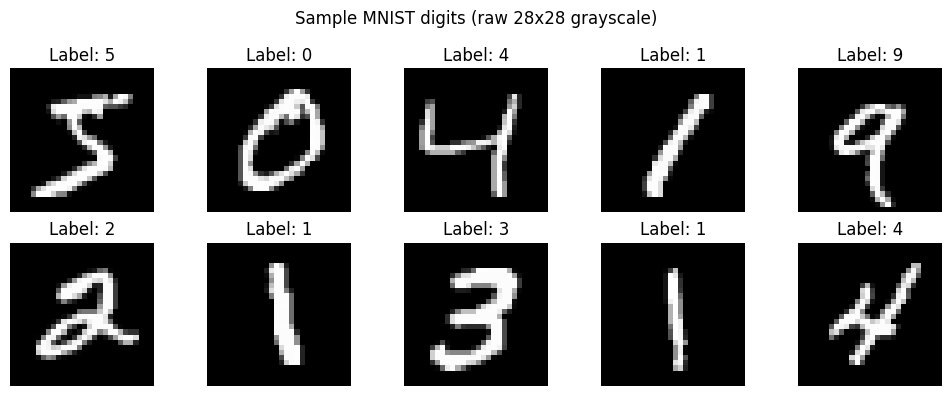

In [5]:
# Look at the class distribution of the raw training set
train_targets = np.array(mnist_train_full.targets)
unique, counts = np.unique(train_targets, return_counts=True)
print("Class distribution in full training set:")
for cls, cnt in zip(unique, counts):
    print(f"  Digit {cls}: {cnt} images")

# Visualize a handful of sample digits to confirm the data looks correct
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = mnist_train_full[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("Sample MNIST digits (raw 28x28 grayscale)")
plt.tight_layout()
plt.show()

## 5. Train/Validation/Test Split

In [6]:
# Split the original 60,000 training images into 54,000 train / 6,000
# validation using a STRATIFIED split so class balance is preserved.
# The original 10,000-image test set stays completely separate.
all_indices = np.arange(len(mnist_train_full))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=6000,
    stratify=train_targets,
    random_state=SEED,
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(mnist_test_full))

# Sanity check: indices must not overlap
assert len(set(train_indices).intersection(set(val_indices))) == 0

Training samples: 54000
Validation samples: 6000
Test samples: 10000


## 6. Prepare MNIST for ImageNet Transfer Learning

MNIST images are 28x28 grayscale, but the pretrained ImageNet
architectures expect 3-channel RGB images around 224x224, normalized
with ImageNet statistics. The dataset wrapper below performs this
conversion on-the-fly for every image, so we never mutate the original
arrays in place and never risk accidental double-unsqueezing.

In [7]:
# ImageNet normalization statistics used by all four pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224

# Deterministic transform used for validation and test data
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # 1-channel -> 3-channel RGB
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),    # match ImageNet input size
    transforms.ToTensor(),                          # PIL image -> float tensor in [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Training transform: kept minimal on purpose. We do NOT use
# RandomHorizontalFlip (a flipped digit can change its meaning, e.g. some
# digits become ambiguous) and we avoid aggressive rotation that could
# distort digit identity.
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=5),           # tiny rotation only, for mild robustness
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MNISTSubset(Dataset):
    '''Wraps a subset of an MNIST dataset (by index) and applies a
    given transform lazily, image by image, so nothing is precomputed
    or mutated in bulk.'''

    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.base_dataset[real_idx]
        image = self.transform(image)
        return image, label


# Build the three clean, independent datasets
train_dataset = MNISTSubset(mnist_train_full, train_indices, train_transform)
val_dataset = MNISTSubset(mnist_train_full, val_indices, eval_transform)
test_dataset = MNISTSubset(
    mnist_test_full, np.arange(len(mnist_test_full)), eval_transform
)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 54000
Val dataset size: 6000
Test dataset size: 10000


## 7. DataLoaders

In [8]:
# Batch size kept modest for Colab GPU memory; reduce to 32 if you hit OOM
BATCH_SIZE = 64
NUM_WORKERS = 2

def create_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    # Build train/val/test DataLoaders with the correct shuffle behaviour
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=CUDA_AVAILABLE,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=CUDA_AVAILABLE,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=CUDA_AVAILABLE,
    )
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders()

# Confirm one batch has the expected shape before training anything
sample_images, sample_labels = next(iter(train_loader))
print("Sample batch image shape:", sample_images.shape)  # ~ [64, 3, 224, 224]
print("Sample batch label shape:", sample_labels.shape)  # ~ [64]

Sample batch image shape: torch.Size([64, 3, 224, 224])
Sample batch label shape: torch.Size([64])


## 8. Define Transfer Learning Models

Each builder function loads ImageNet pretrained weights, freezes the
feature-extraction layers, and replaces the final classification layer
with a fresh 10-class head for MNIST digits. We also define shared,
reusable `train_model` / `evaluate_model` functions so all four
architectures go through an identical training/evaluation procedure -
this is what makes the comparison fair.

In [9]:
NUM_CLASSES = 10
LR = 0.001
NUM_EPOCHS = 5  # kept small/configurable for practical Colab runtimes


def _freeze_backbone(model):
    # Freeze every existing parameter; only the new head will be trainable
    for param in model.parameters():
        param.requires_grad = False
    return model


def build_alexnet(num_classes=NUM_CLASSES):
    # Load AlexNet with pretrained ImageNet weights
    model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
    model = _freeze_backbone(model)
    # Replace the final classifier layer (index 6) with a new trainable
    # linear layer that outputs num_classes instead of 1000
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model


def build_vgg16(num_classes=NUM_CLASSES):
    # Load VGG16 with pretrained ImageNet weights
    model = models.vgg16(weights=VGG16_Weights.DEFAULT)
    model = _freeze_backbone(model)
    # Replace the final classifier layer (index 6), same pattern as AlexNet
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model


def build_resnet50(num_classes=NUM_CLASSES):
    # Load ResNet50 with pretrained ImageNet weights
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    model = _freeze_backbone(model)
    # ResNet's final layer is called `fc`, not `classifier`
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_efficientnet(num_classes=NUM_CLASSES):
    # Load EfficientNet-B0 with pretrained ImageNet weights
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model = _freeze_backbone(model)
    # EfficientNet's classifier is a Sequential; index 1 is the Linear layer
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def count_parameters(model):
    # Report total vs trainable parameter counts for fair size comparison
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [10]:
def train_model(model, model_name, train_loader, val_loader,
                 num_epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    '''Reusable training loop shared by all four architectures so the
    comparison uses an identical training procedure for everyone.'''

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only optimize the parameters that are actually trainable (the new head)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_val_acc = 0.0
    best_state_dict = copy.deepcopy(model.state_dict())

    total_start = time.time()
    for epoch in range(num_epochs):
        epoch_start = time.time()

        # ---- Training phase ----
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{num_epochs} [train]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # ---- Validation phase ----
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total
        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        # Track and save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")
        print(f"  Epoch Time: {epoch_time:.2f}s")

    total_time = time.time() - total_start
    print(f"\nBest Validation Accuracy for {model_name}: {best_val_acc:.4f}")
    print(f"Total Training Time for {model_name}: {total_time:.2f}s")

    # Load the best-performing weights before returning
    model.load_state_dict(best_state_dict)
    return model, history, best_val_acc, total_time


def evaluate_model(model, model_name, test_loader, device=DEVICE, class_names=None):
    '''Reusable evaluation routine: computes test loss/accuracy plus a
    full confusion matrix and classification report.'''

    if class_names is None:
        class_names = [str(i) for i in range(10)]

    model = model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()

    all_preds, all_labels = [], []
    loss_sum, total = 0.0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)
            total += labels.size(0)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = loss_sum / total
    test_acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)

    print(f"\n{model_name} - Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    print(f"\n{model_name} Classification Report:\n{report}")

    return test_loss, test_acc, cm, report


# Storage for results across all four models
results = []          # list of dicts -> becomes the final comparison DataFrame
histories = {}         # model_name -> training history dict
confusion_matrices = {}  # model_name -> confusion matrix array
CLASS_NAMES = [str(i) for i in range(10)]
os.makedirs("models", exist_ok=True)

## 9. Train AlexNet

In [11]:
set_seed(SEED)  # reset seed before each model so runs are comparable
model_name = "AlexNet"

current_model = build_alexnet()
total_params, trainable_params = count_parameters(current_model)
print(f"{model_name} - Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

current_model, current_history, current_best_val_acc, current_train_time = train_model(
    current_model, model_name, train_loader, val_loader
)
histories[model_name] = current_history

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 172MB/s]


AlexNet - Total Params: 57,044,810 | Trainable Params: 40,970


AlexNet Epoch 1/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/5
  Train Loss: 0.4493 | Train Accuracy: 0.8541
  Val Loss:   0.2479 | Val Accuracy:   0.9225
  Epoch Time: 130.50s


...

AlexNet Epoch 4/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a

Epoch 4/5
  Train Loss: 0.3209 | Train Accuracy: 0.8945
  Val Loss:   0.1566 | Val Accuracy:   0.9552
  Epoch Time: 120.51s


AlexNet Epoch 5/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 5/5
  Train Loss: 0.3234 | Train Accuracy: 0.8946
  Val Loss:   0.1583 | Val Accuracy:   0.9500
  Epoch Time: 126.46s

Best Validation Accuracy for AlexNet: 0.9552
Total Training Time for AlexNet: 626.81s


## 10. Evaluate AlexNet

In [12]:
test_loss, test_acc, cm, report = evaluate_model(current_model, model_name, test_loader, class_names=CLASS_NAMES)
confusion_matrices[model_name] = cm

results.append({
    "Model": model_name,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Best Validation Accuracy": current_best_val_acc,
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "Training Time (seconds)": current_train_time,
})

# Save the best weights for this model, then free GPU memory before the
# next architecture is trained - we never keep multiple models resident.
torch.save(current_model.state_dict(), f"models/{model_name.lower()}_best.pth")
del current_model
gc.collect()
if CUDA_AVAILABLE:
    torch.cuda.empty_cache()
print(f"{model_name} finished, memory released.")


AlexNet - Test Loss: 0.1402 | Test Accuracy: 0.9565

AlexNet Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.91      0.95      0.93      1032
           3       0.91      0.95      0.93      1010
           4       0.97      0.97      0.97       982
           5       0.94      0.92      0.93       892
           6       0.95      0.97      0.96       958
           7       0.99      0.93      0.96      1028
           8       0.99      0.92      0.95       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

AlexNet finished, memory released.


## 11. Train VGG16

In [13]:
set_seed(SEED)
model_name = "VGG16"

current_model = build_vgg16()
total_params, trainable_params = count_parameters(current_model)
print(f"{model_name} - Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

current_model, current_history, current_best_val_acc, current_train_time = train_model(
    current_model, model_name, train_loader, val_loader
)
histories[model_name] = current_history

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 69.6MB/s]


VGG16 - Total Params: 134,301,514 | Trainable Params: 40,970


VGG16 Epoch 1/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/5
  Train Loss: 0.5444 | Train Accuracy: 0.8237
  Val Loss:   0.3162 | Val Accuracy:   0.9168
  Epoch Time: 286.05s


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 4/5
  Train Loss: 0.3848 | Train Accuracy: 0.8722
  Val Loss:   0.2226 | Val Accuracy:   0.9403
  Epoch Time: 285.11s


VGG16 Epoch 5/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5
  Train Loss: 0.3870 | Train Accuracy: 0.8727
  Val Loss:   0.2296 | Val Accuracy:   0.9355
  Epoch Time: 285.42s

Best Validation Accuracy for VGG16: 0.9403
Total Training Time for VGG16: 1427.77s


## 12. Evaluate VGG16

In [14]:
test_loss, test_acc, cm, report = evaluate_model(current_model, model_name, test_loader, class_names=CLASS_NAMES)
confusion_matrices[model_name] = cm

results.append({
    "Model": model_name,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Best Validation Accuracy": current_best_val_acc,
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "Training Time (seconds)": current_train_time,
})

torch.save(current_model.state_dict(), f"models/{model_name.lower()}_best.pth")
del current_model
gc.collect()
if CUDA_AVAILABLE:
    torch.cuda.empty_cache()
print(f"{model_name} finished, memory released.")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


VGG16 - Test Loss: 0.2074 | Test Accuracy: 0.9458

VGG16 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       980
           1       1.00      0.97      0.98      1135
           2       0.93      0.94      0.93      1032
           3       0.93      0.93      0.93      1010
           4       0.94      0.95      0.95       982
           5       0.89      0.92      0.91       892
           6       0.98      0.94      0.96       958
           7       0.94      0.95      0.94      1028
           8       0.95      0.95      0.95       974
           9       0.96      0.91      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

VGG16 finished, memory released.


## 13. Train ResNet50

In [15]:
set_seed(SEED)
model_name = "ResNet50"

current_model = build_resnet50()
total_params, trainable_params = count_parameters(current_model)
print(f"{model_name} - Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

current_model, current_history, current_best_val_acc, current_train_time = train_model(
    current_model, model_name, train_loader, val_loader
)
histories[model_name] = current_history

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.6MB/s]


ResNet50 - Total Params: 23,528,522 | Trainable Params: 20,490


ResNet50 Epoch 1/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/5
  Train Loss: 0.7933 | Train Accuracy: 0.8087
  Val Loss:   0.4697 | Val Accuracy:   0.8893
  Epoch Time: 195.91s


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 4/5
  Train Loss: 0.2815 | Train Accuracy: 0.9207
  Val Loss:   0.2742 | Val Accuracy:   0.9235
  Epoch Time: 196.29s


ResNet50 Epoch 5/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5
  Train Loss: 0.2553 | Train Accuracy: 0.9254
  Val Loss:   0.2674 | Val Accuracy:   0.9258
  Epoch Time: 197.31s

Best Validation Accuracy for ResNet50: 0.9258
Total Training Time for ResNet50: 980.87s


## 14. Evaluate ResNet50

In [16]:
test_loss, test_acc, cm, report = evaluate_model(current_model, model_name, test_loader, class_names=CLASS_NAMES)
confusion_matrices[model_name] = cm

results.append({
    "Model": model_name,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Best Validation Accuracy": current_best_val_acc,
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "Training Time (seconds)": current_train_time,
})

torch.save(current_model.state_dict(), f"models/{model_name.lower()}_best.pth")
del current_model
gc.collect()
if CUDA_AVAILABLE:
    torch.cuda.empty_cache()
print(f"{model_name} finished, memory released.")


ResNet50 - Test Loss: 0.2541 | Test Accuracy: 0.9277

ResNet50 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.98      0.99      0.98      1135
           2       0.93      0.83      0.87      1032
           3       0.87      0.91      0.89      1010
           4       0.95      0.95      0.95       982
           5       0.88      0.89      0.89       892
           6       0.92      0.96      0.94       958
           7       0.91      0.95      0.93      1028
           8       0.92      0.93      0.92       974
           9       0.95      0.91      0.93      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

ResNet50 finished, memory released.


## 15. Train EfficientNetB0

In [27]:
set_seed(SEED)
model_name = "EfficientNetB0"

current_model = build_efficientnet()
total_params, trainable_params = count_parameters(current_model)
print(f"{model_name} - Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

current_model, current_history, current_best_val_acc, current_train_time = train_model(
    current_model, model_name, train_loader, val_loader
)
histories[model_name] = current_history

EfficientNetB0 - Total Params: 4,020,358 | Trainable Params: 12,810


EfficientNetB0 Epoch 1/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in: AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>: can only test a child process

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 1/5
  Train Loss: 0.5584 | Train Accuracy: 0.8537
  Val Loss:   0.2447 | Val Accuracy:   0.9328
  Epoch Time: 147.10s


EfficientNetB0 Epoch 2/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 4/5
  Train Loss: 0.2812 | Train Accuracy: 0.9101
  Val Loss:   0.1739 | Val Accuracy:   0.9438
  Epoch Time: 135.56s


EfficientNetB0 Epoch 5/5 [train]:   0%|          | 0/844 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d688d1e6160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5
  Train Loss: 0.2718 | Train Accuracy: 0.9143
  Val Loss:   0.1614 | Val Accuracy:   0.9502
  Epoch Time: 136.03s

Best Validation Accuracy for EfficientNetB0: 0.9502
Total Training Time for EfficientNetB0: 689.43s


## 16. Evaluate EfficientNetB0

In [29]:
test_loss, test_acc, cm, report = evaluate_model(current_model, model_name, test_loader, class_names=CLASS_NAMES)
confusion_matrices[model_name] = cm

results.append({
    "Model": model_name,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Best Validation Accuracy": current_best_val_acc,
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "Training Time (seconds)": current_train_time,
})

torch.save(current_model.state_dict(), f"models/{model_name.lower()}_best.pth")
del current_model
gc.collect()
if CUDA_AVAILABLE:
    torch.cuda.empty_cache()
print(f"{model_name} finished, memory released.")


EfficientNetB0 - Test Loss: 0.1413 | Test Accuracy: 0.9555

EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.98      0.99      0.99      1135
           2       0.94      0.93      0.93      1032
           3       0.95      0.95      0.95      1010
           4       0.97      0.95      0.96       982
           5       0.93      0.93      0.93       892
           6       0.97      0.95      0.96       958
           7       0.95      0.97      0.96      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000

EfficientNetB0 finished, memory released.


## 17. Compare All Models

In [19]:
# Build the results DataFrame from the values recorded for each model.
# All numbers here come directly from actual training/evaluation runs.
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Total Parameters,Trainable Parameters,Best Validation Accuracy,Test Accuracy,Test Loss,Training Time (seconds)
0,AlexNet,57044810,40970,0.955167,0.9565,0.140185,626.813698
1,EfficientNetB0,4020358,12810,0.950167,0.9555,0.141261,708.818312
2,VGG16,134301514,40970,0.940333,0.9458,0.207389,1427.765532
3,ResNet50,23528522,20490,0.925833,0.9277,0.254088,980.872405


## 18. Plot Accuracy and Loss

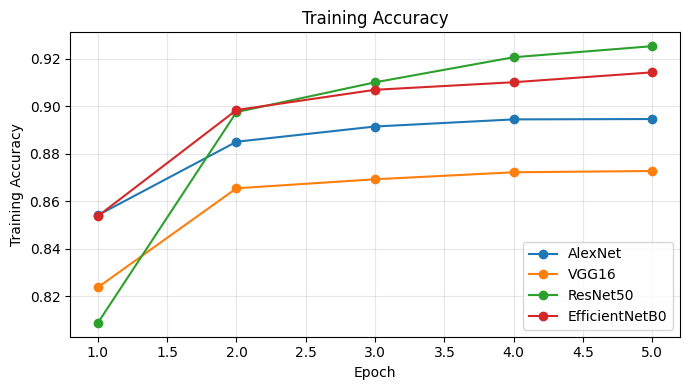

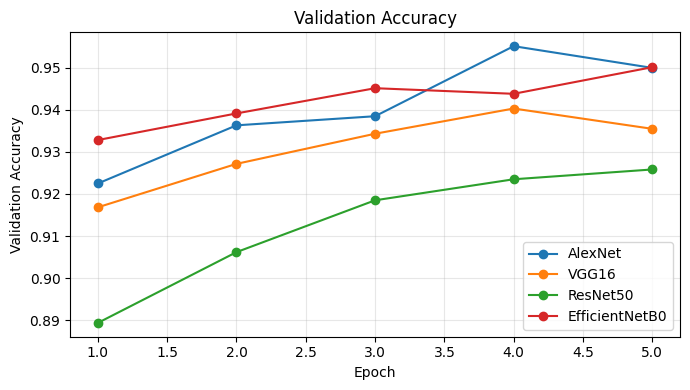

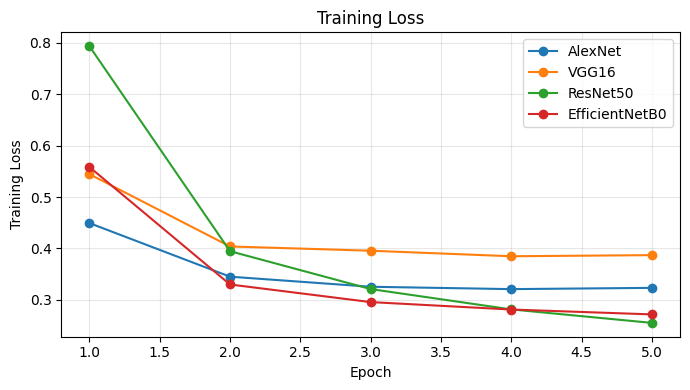

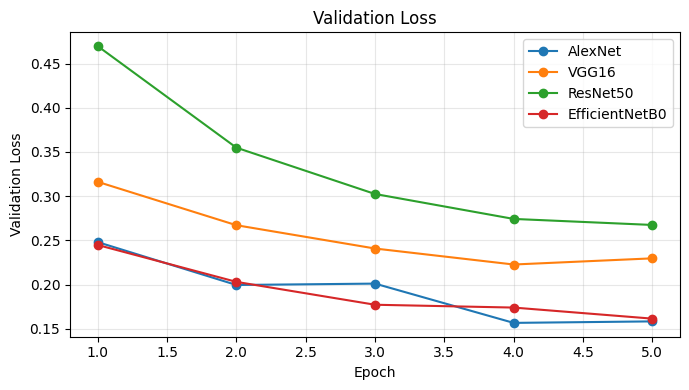

In [20]:
def plot_training_history(histories):
    # One clear comparison plot each for train acc, val acc, train loss, val loss
    metrics = [
        ("train_acc", "Training Accuracy"),
        ("val_acc", "Validation Accuracy"),
        ("train_loss", "Training Loss"),
        ("val_loss", "Validation Loss"),
    ]
    for key, title in metrics:
        plt.figure(figsize=(7, 4))
        for model_name, history in histories.items():
            epochs = range(1, len(history[key]) + 1)
            plt.plot(epochs, history[key], marker="o", label=model_name)
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_training_history(histories)

## 19. Compare Training Time

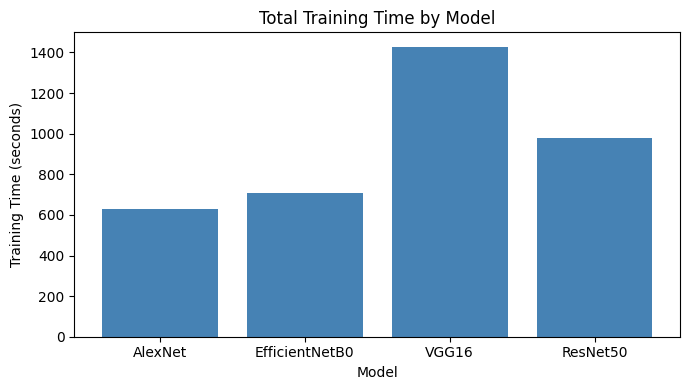

Training time per model (seconds):
  AlexNet: 626.81s
  EfficientNetB0: 708.82s
  VGG16: 1427.77s
  ResNet50: 980.87s


In [21]:
# Bar chart comparing total training time across all four models
plt.figure(figsize=(7, 4))
plt.bar(results_df["Model"], results_df["Training Time (seconds)"], color="steelblue")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Total Training Time by Model")
plt.tight_layout()
plt.show()

print("Training time per model (seconds):")
for _, row in results_df.iterrows():
    print(f"  {row['Model']}: {row['Training Time (seconds)']:.2f}s")

## 20. Confusion Matrices

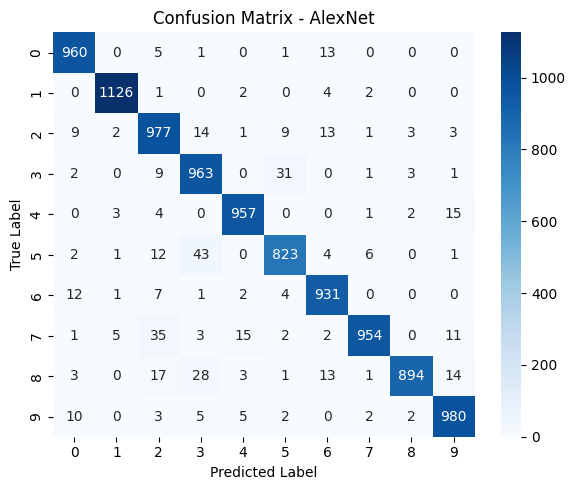

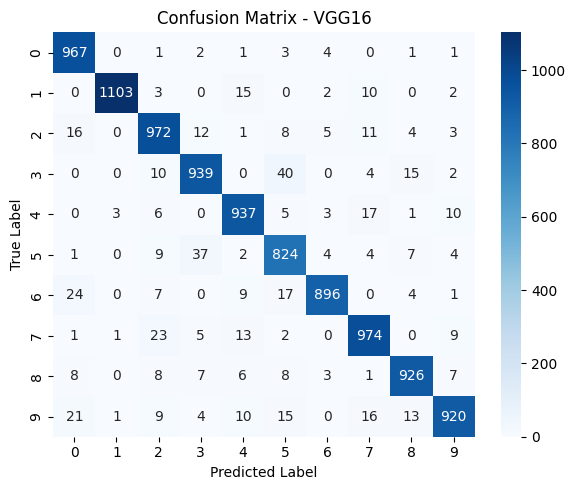

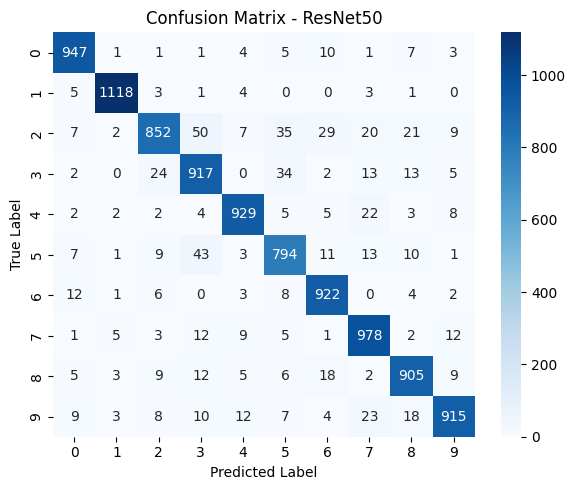

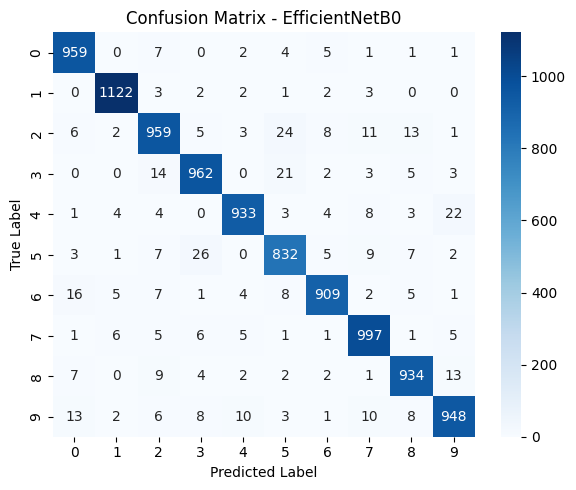

In [22]:
def plot_confusion_matrix(cm, class_names, model_name):
    # Predicted label on x-axis, true label on y-axis, as requested
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

for model_name, cm in confusion_matrices.items():
    plot_confusion_matrix(cm, CLASS_NAMES, model_name)

## 21. Final Results Table

In [23]:
# Display the comparison table sorted by test accuracy (already sorted above)
print(results_df.to_string(index=False))

# Persist the comparison table to disk as requested
results_df.to_csv("model_comparison.csv", index=False)
print("\nSaved comparison table to model_comparison.csv")
print("Saved best model weights to the models/ directory")

         Model  Total Parameters  Trainable Parameters  Best Validation Accuracy  Test Accuracy  Test Loss  Training Time (seconds)
       AlexNet          57044810                 40970                  0.955167         0.9565   0.140185               626.813698
EfficientNetB0           4020358                 12810                  0.950167         0.9555   0.141261               708.818312
         VGG16         134301514                 40970                  0.940333         0.9458   0.207389              1427.765532
      ResNet50          23528522                 20490                  0.925833         0.9277   0.254088               980.872405

Saved comparison table to model_comparison.csv
Saved best model weights to the models/ directory


In [24]:
# Clean, final printed summary using ONLY the actual recorded values
print("=" * 40)
print("FINAL MODEL COMPARISON")
print("=" * 40)
for _, row in results_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"Test Accuracy: {row['Test Accuracy'] * 100:.2f}%")
    print(f"Training Time: {row['Training Time (seconds)']:.2f} seconds")

best_model_row = results_df.iloc[0]
print(f"\nBest Model: {best_model_row['Model']} "
      f"(Test Accuracy: {best_model_row['Test Accuracy'] * 100:.2f}%)")

FINAL MODEL COMPARISON

Model: AlexNet
Test Accuracy: 95.65%
Training Time: 626.81 seconds

Model: EfficientNetB0
Test Accuracy: 95.55%
Training Time: 708.82 seconds

Model: VGG16
Test Accuracy: 94.58%
Training Time: 1427.77 seconds

Model: ResNet50
Test Accuracy: 92.77%
Training Time: 980.87 seconds

Best Model: AlexNet (Test Accuracy: 95.65%)


## 22. Final Conclusion

In [28]:
# Automatically derive the conclusion talking points from results_df -
# nothing here is hard-coded or invented.
best_acc_row = results_df.loc[results_df["Test Accuracy"].idxmax()]
fastest_row = results_df.loc[results_df["Training Time (seconds)"].idxmin()]
largest_row = results_df.loc[results_df["Total Parameters"].idxmax()]
smallest_row = results_df.loc[results_df["Total Parameters"].idxmin()]

conclusion = f"""

================

- Highest test accuracy: {best_acc_row['Model']} ({best_acc_row['Test Accuracy']*100:.2f}%)
- Shortest training time: {fastest_row['Model']} ({fastest_row['Training Time (seconds)']:.2f}s)
- Largest model (most parameters): {largest_row['Model']} ({largest_row['Total Parameters']:,} params)
- Smallest model (fewest parameters): {smallest_row['Model']} ({smallest_row['Total Parameters']:,} params)


"""

print(conclusion)




- Highest test accuracy: AlexNet (95.65%)
- Shortest training time: AlexNet (626.81s)
- Largest model (most parameters): VGG16 (134,301,514 params)
- Smallest model (fewest parameters): EfficientNetB0 (4,020,358 params)



